<a href="https://colab.research.google.com/github/Siddwayy/data-visualization-projects/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_16361/2143872479.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


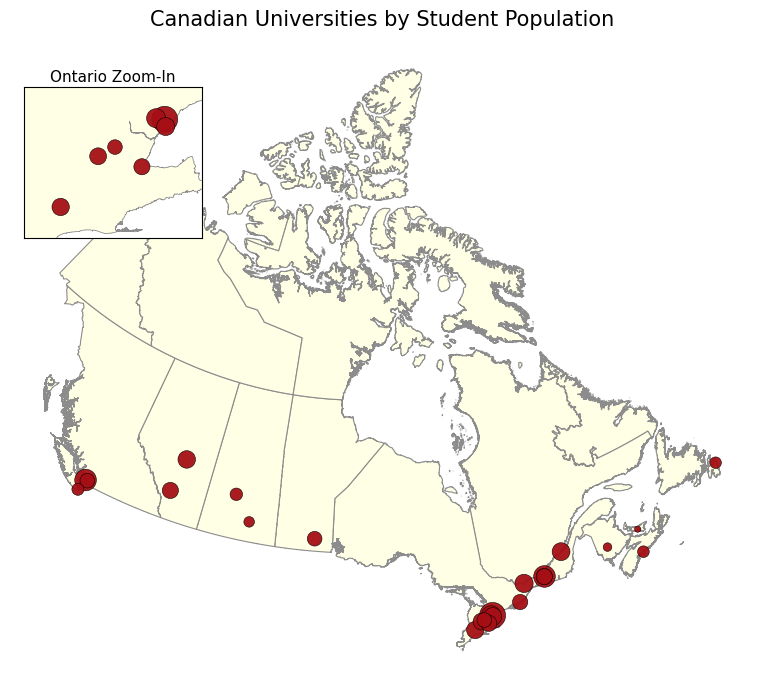

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
import pandas as pd

root = Path('.')
unis = gpd.read_file(root / 'universities.geojson')
canada = gpd.read_file(root / 'canada.shp')

if unis.crs is None:
    unis = unis.set_crs('EPSG:4326')
unis = unis.to_crs(canada.crs)

name_candidates = ['name', 'university', 'institution', 'school', 'uni_name']
enrol_candidates = ['students', 'total_students', 'total students', 'enrolment', 'enrollment', 'student_pop', 'population']

def normalize_key(s):
    return ''.join(ch for ch in str(s).lower() if ch.isalnum())

def pick_col(df, candidates):
    norm_to_col = {normalize_key(c): c for c in df.columns}
    for c in candidates:
        key = normalize_key(c)
        if key in norm_to_col:
            return norm_to_col[key]
    return None

name_col = pick_col(unis, name_candidates)
enrol_col = pick_col(unis, enrol_candidates)

if name_col is None:
    raise ValueError(f'Could not find a university-name column. Available columns: {list(unis.columns)}')
if enrol_col is None:
    raise ValueError(f'Could not find a student-enrollment column. Available columns: {list(unis.columns)}')

unis[enrol_col] = pd.to_numeric(unis[enrol_col], errors='coerce')
unis = unis.dropna(subset=[enrol_col]).copy()

min_s, max_s = 20, 350
vals = unis[enrol_col].astype(float)
unis['sym_size'] = (min_s + (vals - vals.min()) * (max_s - min_s) / (vals.max() - vals.min())) if vals.max() != vals.min() else (min_s + max_s) / 2

fig, ax = plt.subplots(figsize=(12, 7))
canada.plot(ax=ax, facecolor='#FFFFE5', edgecolor='0.55', linewidth=0.8)
unis.plot(ax=ax, color='#A50F15', markersize=unis['sym_size'], alpha=0.95, edgecolor='black', linewidth=0.4)
ax.set_title('Canadian Universities by Student Population', fontsize=15, pad=10)
ax.set_axis_off()

def match_target(n):
    s = str(n).lower()
    checks = [
        'university of toronto',
        'toronto metropolitan',
        'york university',
        'university of waterloo',
        'university of guelph',
        'mcmaster',
        'university of western ontario',
        'western university'
    ]
    return any(k in s for k in checks)

ontario7 = unis[unis[name_col].apply(match_target)].copy()
axins = inset_axes(ax, width='24%', height='34%', loc='upper left', borderpad=1.0)
canada.plot(ax=axins, facecolor='#FFFFE5', edgecolor='0.55', linewidth=0.6)

if not ontario7.empty:
    ontario7.plot(ax=axins, color='#A50F15', markersize=ontario7['sym_size'], alpha=0.95, edgecolor='black', linewidth=0.4)
    minx, miny, maxx, maxy = ontario7.total_bounds
    dx, dy = maxx - minx, maxy - miny
    axins.set_xlim(minx - (dx * 0.35 if dx > 0 else 60000), maxx + (dx * 0.35 if dx > 0 else 60000))
    axins.set_ylim(miny - (dy * 0.35 if dy > 0 else 60000), maxy + (dy * 0.35 if dy > 0 else 60000))

axins.set_title('Ontario Zoom-In', fontsize=11, pad=4)
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.tight_layout()
plt.show()


#Q2#

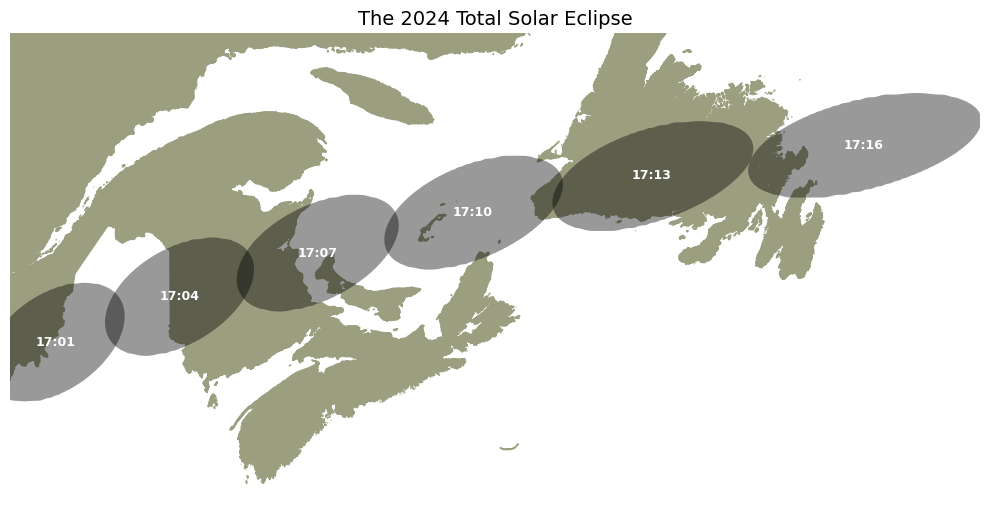

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

umbra = gpd.read_file('umbra_lo.shp')
canada = gpd.read_file('canada.shp')

canada = canada.to_crs(umbra.crs)

shadow_utc_times = ['19:31:00', '19:34:00', '19:37:00', '19:40:00', '19:43:00', '19:46:00']
shadows = umbra[umbra['UTCTime'].isin(shadow_utc_times)].copy()

ndt_labels = ['17:01', '17:04', '17:07', '17:10', '17:13', '17:16']
utc_to_ndt = dict(zip(shadow_utc_times, ndt_labels))
shadows['NDT'] = shadows['UTCTime'].map(utc_to_ndt)

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

canada.plot(ax=ax, color='#9B9E7F', edgecolor='#9B9E7F')

shadows.plot(ax=ax, color='black', alpha=0.4, edgecolor='none')

for _, row in shadows.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['NDT'], xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlim(-71.5, -49)
ax.set_ylim(43, 50.5)
ax.set_title('The 2024 Total Solar Eclipse', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [9]:
import geopandas as gpd
import folium
import json

umbra = gpd.read_file('umbra_lo.shp')

shadow_utc_times = ['19:31:00', '19:34:00', '19:37:00', '19:40:00', '19:43:00', '19:46:00']
shadows = umbra[umbra['UTCTime'].isin(shadow_utc_times)].copy()

center_lat = shadows['CenterLat'].mean()
center_lon = shadows['CenterLon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community'
)

geojson_data = json.loads(shadows.to_json())

folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': 'grey',
        'color': 'grey',
        'weight': 1,
        'fillOpacity': 0.5,
    }
).add_to(m)

m